In [48]:
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
from langgraph.graph import StateGraph,END,START
from typing import TypedDict
from dotenv import load_dotenv


In [70]:
load_dotenv()
# llm = HuggingFaceEndpoint(
#     repo_id="HuggingFaceTB/SmolLM2-1.7B-Instruct",
#     task="text-generation",
# )
# load_dotenv()
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",
)
model = ChatHuggingFace(llm=llm)
# model2 = ChatHuggingFace(llm=llm2)

In [80]:
# create state
class BlogState(TypedDict):

    title :str
    outline :str
    content :str
    evaluate:str

In [85]:
def create_outline(state:BlogState)->BlogState:

    # extract tittle
    title = state['title']

    # create prompt
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'

    # call llm gen outline
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline
    
    return state


def create_blog(state:BlogState)->BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'

    content = model.invoke(prompt).content
    state['content'] = content

    return state
    
def evaluate_my_blog(state:BlogState)->BlogState:

    outline = state['outline']
    content = state['content']

    prompt = f'Based on this outline - {outline}, Rate my Blog \n {content}'

    evaluate = model.invoke(prompt).content

    state['evaluate'] = evaluate
    return state

In [86]:
# create graph
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('evaluate_my_blog',evaluate_my_blog)

#edges
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluate_my_blog')
graph.add_edge('evaluate_my_blog',END)

#compile
workflow = graph.compile()

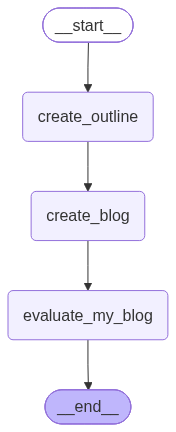

In [87]:
workflow

In [88]:
#execute
initial_state = {'title':"Fifa Worldcup"}
final_state = workflow.invoke(initial_state)

In [89]:
print(final_state)

{'title': 'Fifa Worldcup', 'outline': 'Here is a detailed outline for a blog on the topic "FIFA World Cup":\n\n**I. Introduction**\n\n* Brief overview of the FIFA World Cup\n* Importance of the World Cup in international football\n* Objective of the blog: to provide an in-depth look at the history, format, and impact of the FIFA World Cup\n\n**II. History of the FIFA World Cup**\n\n* Origins of the World Cup: the first tournament in 1930\n* Early years: the 1930s to 1950s\n* Expansion and growth: the 1960s to 1980s\n* Modern era: the 1990s to present day\n\n**III. Format of the FIFA World Cup**\n\n* Qualification process: how teams qualify for the tournament\n* Group stage: the format and teams involved\n* Knockout stage: the quarterfinals, semifinals, and final\n* Trophies and awards: the winner\'s medal, the Golden Ball, and the Golden Boot\n\n**IV. Notable Moments in World Cup History**\n\n* Upsets and surprises: teams that have beaten the odds\n* Comebacks and dramatic finishes: te

In [92]:
print(final_state['evaluate'])

I'd be happy to help you rate your blog on "The Beautiful Game: A Comprehensive Guide to the FIFA World Cup".

**Rating: 9/10**

**Strengths:**

1. **Comprehensive structure**: Your outline covers all aspects of the FIFA World Cup, from its history to its format, notable moments, and impact on football and society.
2. **Detailed information**: Your blog provides a wealth of information on the World Cup, including its history, format, and notable moments, which will surely engage readers.
3. **Organization**: Your outline is well-organized, with clear headings and subheadings that make it easy to follow.
4. **Thorough research**: Your blog demonstrates thorough research on the topic, with accurate information and statistics.

**Weaknesses:**

1. **Lack of engaging introduction**: While your introduction provides a brief overview of the World Cup, it could be more engaging and enticing to readers.
2. **Some sections could be expanded**: While your outline is comprehensive, some sections,